# 03 · Results and the next decision

**Current decision: competition performance remains open.** The original lexical submission scored **0.59191 public / 0.61956 private**, below the approximately **0.92** objective. A successful submission did not complete the performance goal. The historical research below used post-competition development labels and remains a separate, preserved result. The new original-data representation study reopens the feature gate; [the rebuild record](../docs/COMPETITION_REBUILD.md) explains the failure and next acceptance steps.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
import plotly.io as pio
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

# Every figure also supplies an SVG fallback. Keep JavaScript bundles out of the notebook.
pio.renderers.default = "plotly_mimetype"

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from jigsaw_rules.formatting import formatting_evidence
from jigsaw_rules.feature_decision import decision_evidence
from build_expanded_report import display_figure as display_expanded
from build_formatting_report import display_figure as display_formatting

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
formatting = formatting_evidence(root)
decision = decision_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
assert formatting is not None and decision is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## Competition rebuild: richer rule and example representations

**Question:** At a fixed 4B backbone and classifier, do joint context and representation interactions improve policy transfer? The extractor never receives development targets. All learned screens and classifiers fit inside purged training folds. These are repeated development measurements on two policies, not a new holdout or a Kaggle score. The original lexical submission remains the recorded baseline.

Inference run: fe1da83fc62341bf608d
Unique candidate columns: 15369
Fixed classifier fits: 45


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,lexical_reference,Held-out rule,0.6156,0.6736,0.2405,0.6241
1,rule_raw,Held-out rule,0.7081,6.0601,0.4342,0.6647
2,support_raw,Held-out rule,0.5747,3.4501,0.4540,0.5811
3,rule_support_raw,Held-out rule,0.7056,5.5933,0.4393,0.6671
4,rule_likelihood,Held-out rule,0.7021,0.7774,0.2824,0.5701
5,rule_embedding,Held-out rule,0.5508,1.1337,0.3541,0.4937
6,support_likelihood,Held-out rule,0.3644,0.8485,0.3205,0.4181
7,support_embedding,Held-out rule,0.5312,0.8915,0.3133,0.5027
8,rule_support_likelihood,Held-out rule,0.6903,0.8246,0.2959,0.5971
9,rule_support_embedding,Held-out rule,0.4881,1.7367,0.4570,0.4694


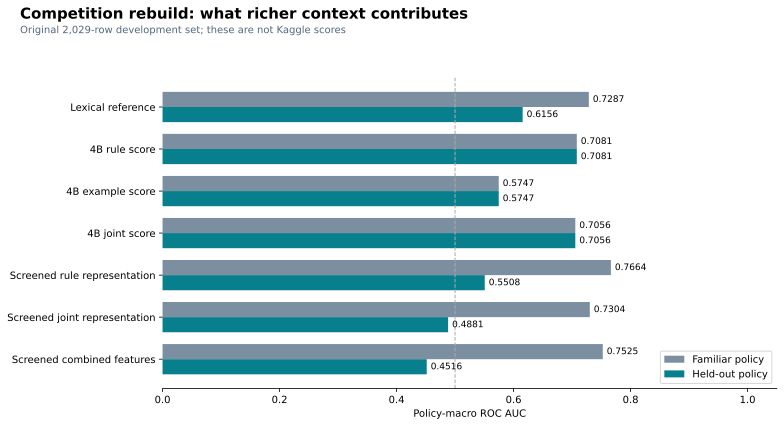

In [3]:
import sys
sys.path.insert(0, str(root / 'scripts'))
from build_competition_report import evidence as competition_evidence, display_comparison
competition = competition_evidence(root)
print('Inference run:', competition['provenance']['inference_run_id'])
print('Unique candidate columns:', competition['protocol']['unique_candidates'])
print('Fixed classifier fits:', competition['protocol']['fixed_classifier_fits'])
display(metric_table(competition['results'], heldout=True))
display_comparison(root)

## Learn the new rule from its supplied examples

**Question:** Does task-specific representation learning improve genuinely novel comments when labeled supports for a new rule are available? This is a support-adaptation test, distinct from zero-shot transfer. The same 4B model and rule-only prompt are compared before and after one fixed epoch of LoRA. Query labels never enter the GPU input, and every query body is purged from all fitting sources. The classical readouts and prototype features use only that policy's known support labels.

The cohort contains 881 original-data comments across two previously examined policies; 1,148 comments present in a supplied support pool are excluded. This is development evidence, not a new untouched test or a Kaggle score. Frozen/adapted comparisons isolate representation learning, while prototype additions compare features at the same adapted backbone.

Cloud run: d13858b7407993fcc6e8
Novel evaluation comments: 881
Candidate coordinates and geometry columns: 5138
Policy 1: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.
Policy 2: No legal advice: Do not offer or request legal advice.


,Representation,Policy-macro AUC,Policy 1 AUC,Policy 2 AUC
0,frozen_raw,0.6146,0.5705,0.6587
1,frozen_screened_embedding,0.6715,0.5855,0.7575
2,frozen_centroid,0.6434,0.5954,0.6914
3,frozen_nearest,0.6622,0.6028,0.7215
4,frozen_top5,0.7013,0.6644,0.7382
5,frozen_geometry_blend,0.6499,0.5994,0.7003
6,adapted_raw,0.7199,0.6793,0.7605
7,adapted_screened_embedding,0.7174,0.6754,0.7593
8,adapted_centroid,0.7185,0.6708,0.7661
9,adapted_nearest,0.6791,0.6385,0.7196


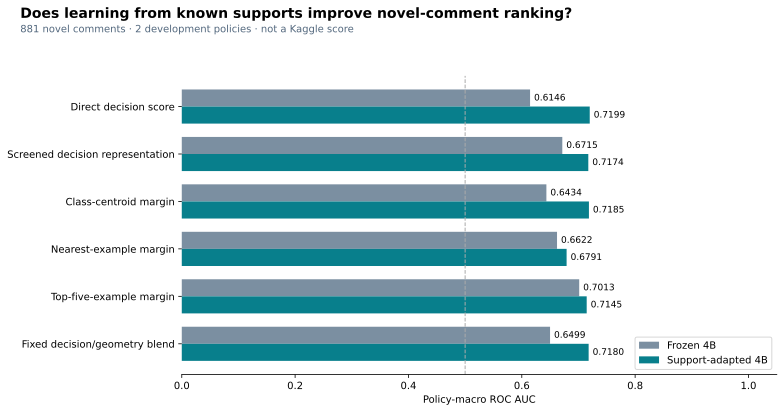

In [4]:
from build_adaptation_report import evidence as adaptation_evidence, display_comparison as display_adaptation
adaptation = adaptation_evidence(root)
print('Cloud run:', adaptation['inference']['run_id'])
print('Novel evaluation comments:', adaptation['protocol']['rows'])
print('Candidate coordinates and geometry columns:', adaptation['protocol']['unique_candidate_columns'])
policies = sorted(adaptation['results'][0]['metrics']['per_rule_auc'])
for i, policy in enumerate(policies, 1):
    print(f'Policy {i}:', policy)
comparison_rows = []
for record in adaptation['results']:
    comparison_rows.append({'Representation': record['model'], 'Policy-macro AUC': record['metrics']['rule_macro_auc'], **{f'Policy {i} AUC': record['metrics']['per_rule_auc'][policy] for i, policy in enumerate(policies, 1)}})
display(pd.DataFrame(comparison_rows).round(4))
display_adaptation(root)

## Historical post-competition research

The preserved study below uses organizer-released labels and has its own consumed protected cohort. Its scores and stopping decision do not close the original-competition performance objective.

## Protected confirmation: all 12 fixed checks pass
Predictions were frozen in published commit `530ad79929012e807cb42a5253f7b92b090682ec` before eligible target access on September 9, 2026. The primary six-policy macro AUC improves from **0.6801 to 0.7770**, a **+0.0969** gain with paired 95% interval **[0.0898, 0.1051]**. Familiar-policy AUC reaches **0.8276** and unseen-policy AUC **0.6757**; every policy improves.

Overall log loss falls from 0.6685 to 0.5121, and Brier from 0.2360 to 0.1739. This is one fixed post-competition comparison on **43,509 rows**, including two policies wholly excluded from development. The interval conditions on six observed policies. No candidate was retuned on these targets; this is not a Kaggle score. [Frozen protocol and recovery](../docs/CONFIRMATION.md).

Protected decision: accepted


sufficient_policy_class_counts    True
minimum_macro_auc_gain            True
positive_primary_interval         True
maximum_policy_auc_drop           True
positive_familiar_gain            True
positive_unseen_gain              True
all_log_loss_guard                True
familiar_log_loss_guard           True
unseen_log_loss_guard             True
all_brier_guard                   True
familiar_brier_guard              True
unseen_brier_guard                True
Name: Passed preregistered check, dtype: bool

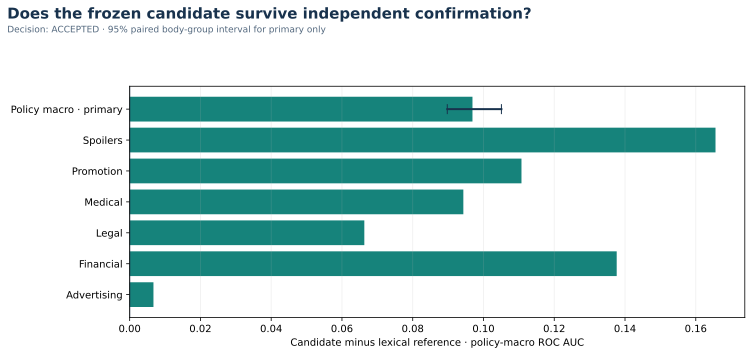

In [5]:
from jigsaw_rules.confirmation_report import confirmation_evidence
from build_protected_report import display_figure as display_protected
protected = confirmation_evidence(root)
assert protected is not None
print("Protected decision:", protected["results"]["status"])
display(pd.Series(protected["results"]["checks"], name="Passed preregistered check"))
display_protected(root, "policy_gains")

## What the expanded research measured
Thirty-four fixed trained configurations share seven purged splits. The feature study adds/removes major families, checks full versus screened representations, and tests training-only NB/SVD controls. Frozen semantic scores are untrained comparison baselines. The 43,576-row reserve remains outside model selection.

The frozen semantic centroid reaches **0.7042 transfer AUC**, versus **0.4728** for the matched lexical reference. Its log loss improves from 0.8126 to 0.6237. Most of the gain comes from avoiding reversed lexical ranking on illegal-activity promotion; legal and medical advice remain difficult. The all-transfer model reaches 0.7989 on familiar policies but only 0.5515 on transfer.

Policy-macro AUC is the primary competition-oriented metric. These are post-competition development results, not a Kaggle score.

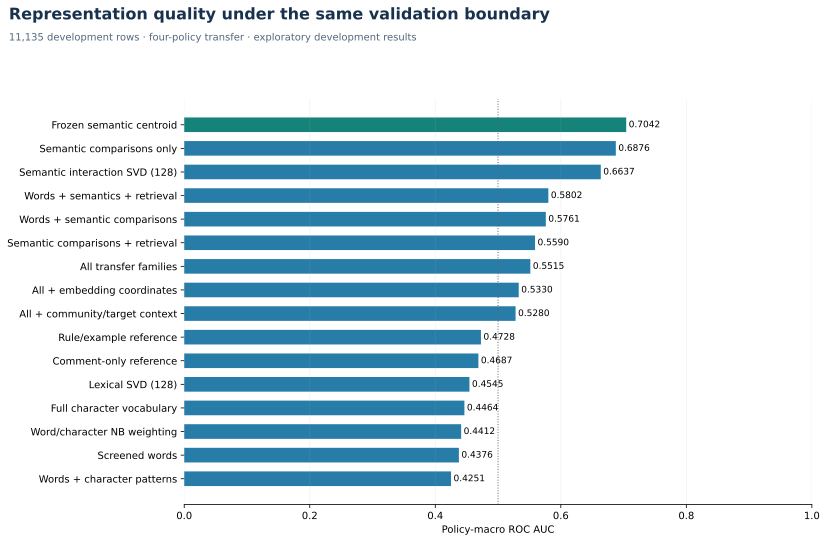

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
7,centroid_intent_mean (rejected),Held-out rule,0.7086,0.6549,0.2320,0.7039
1,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
6,semantic_intent,Held-out rule,0.6909,0.7495,0.2682,0.6206
3,semantic_scalar_only,Held-out rule,0.6876,0.6891,0.2456,0.6872
5,asymmetric_centroid,Held-out rule,0.6865,0.6214,0.2170,0.7554
4,word_semantic_scalar,Held-out rule,0.5761,0.8156,0.2969,0.5727
0,all_transfer,Held-out rule,0.5515,1.4700,0.4503,0.5057
2,rule_examples,Held-out rule,0.4728,0.8126,0.2992,0.5294


In [6]:
display_expanded(root, "comparison")
selected = {"rule_examples", "word_semantic_scalar", "semantic_scalar_only", "qwen_centroid", "all_transfer"}
rows = [r for r in expanded["results"] if r["model"] in selected]
rows += [r for r in formatting["results"] if r["model"] in {"asymmetric_centroid", "semantic_intent"}]
rows += [{"model": "centroid_intent_mean (rejected)", "protocol": "heldout_rule", "metrics": decision["fusion"]["metrics"]}]
display(metric_table(rows, heldout=True).sort_values("Rule macro AUC", ascending=False))

## What would count as a feature improvement?
The family-ablation figure in notebook `02` measures additions to the same screened-word control. The table below compares each representation with the same-fold rule/example reference. A higher point estimate with an interval crossing zero remains an uncertain development observation. Probability losses and policy-level failures are part of the decision. Simultaneous intervals apply within each preregistered study; combining rows below does not create one joint correction over all research.

In [7]:
contrasts = pd.DataFrame(expanded["uncertainty"] + retrieval["uncertainty"])
compared = contrasts[(contrasts.protocol == "heldout_rule") & (contrasts.reference == "rule_examples")]
display(compared.sort_values("observed_delta", ascending=False).head(10)[["candidate", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

,candidate,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
73,qwen_centroid,0.2314,0.1985,0.2600,0.1889,0.2740
76,qwen_kernel_0.2,0.2208,0.1879,0.2488,0.1782,0.2633
77,qwen_kernel_0.5,0.2206,0.1875,0.2487,0.1780,0.2631
75,qwen_kernel_0.1,0.2202,0.1872,0.2484,0.1776,0.2627
79,qwen_mean,0.2200,0.1867,0.2481,0.1775,0.2626
74,qwen_kernel_0.05,0.2180,0.1846,0.2456,0.1755,0.2606
82,semantic_scalar_only,0.2149,0.1802,0.2428,0.1723,0.2574
78,qwen_maximum,0.2122,0.1789,0.2404,0.1696,0.2547
71,latent_qwen_interaction,0.1909,0.1527,0.2222,0.1484,0.2335
83,without_character,0.1183,0.0835,0.1532,0.0757,0.1608


## Why the feature search stopped
The campaign covers 188,595–188,598 candidate columns per fold and 323 fixed fits. Training screens retain 9,281–9,660 columns across separate banks. The strongest transfer representation is simpler than those banks: a frozen support-centroid comparison. The last semantic variants fail the declared acceptance rule. A fixed average has the highest point AUC (0.7086), but its gain is uncertain and probability/policy regressions fail all five checks. The stopping decision retains 0.7042, rather than selecting the largest reported number.

The fixed route now has executed development evidence. Nine nested inner fits isolate calibration from outer validation labels; all three reconstructed familiar models reproduce their saved predictions within 1.2e-16. Familiar calibration passes all six gates; unseen calibration fails four and is discarded. One candidate and one lexical reference are fitted on all 11,135 development rows. The exact candidate/reference and acceptance protocol were committed before protected scoring; prediction hashes were published before eligible labels were interpreted.

The standalone inference notebook still uses the named lexical reference. The accepted benchmark artifact is now packaged for offline inference. The authored walkthrough below illustrates familiar and new policies; the model/data cards and release guide state its scope. The original-training-only Kaggle notebook remains separate. [Completed milestone specification](../docs/FINAL_MODEL_PLAN.md).

In [8]:
print("Expanded study:", gate["expanded_development"])
print("Feature gate:", gate["status"])
print("Final training justified:", gate["final_training_authorized_by_evidence"])

Expanded study: {'rows': 11135, 'policies': 4, 'fitted_models': 260}
Feature gate: ready_for_final_model_validation
Final training justified: True


## From features to the fitted candidate
The final familiar pipeline retains **9,263 of 181,958 columns** across seven selected families. It contains no target encodings, community metadata or raw embedding coordinates. Unknown policies bypass this learned pipeline.

Nested calibration improves familiar-policy log loss from **0.4761 to 0.4689**; the paired 97.5% interval for improvement is **[0.0037, 0.0109]**. AUC stays near 0.799. Calibrating the centroid damages transfer log loss from **0.6237 to 0.6976**, so unseen-policy probabilities retain their original mapping. This is a calibration result, separate from feature-engineering gains. [Protocol and full results](../docs/MODEL_VALIDATION.md).

Final selected columns: 9263
Reserved targets accessed during development fitting: False


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,reference,Familiar rules,0.7311,0.5895,0.2029,0.7692
1,raw,Familiar rules,0.7989,0.4761,0.1569,0.8853
2,calibrated,Familiar rules,0.7991,0.4689,0.1550,0.8846
3,reference,Held-out rule,0.4728,0.8126,0.2992,0.5294
4,raw,Held-out rule,0.7042,0.6237,0.2177,0.7559
5,calibrated,Held-out rule,0.7042,0.6976,0.2479,0.6404


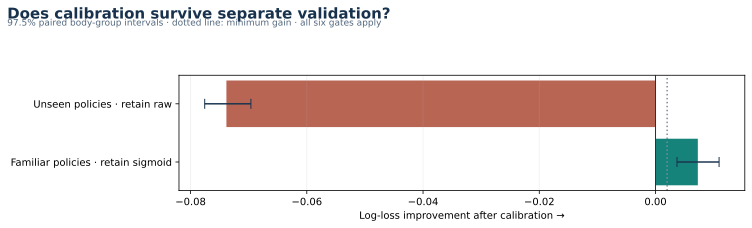

In [9]:
from jigsaw_rules.model_validation import validation_evidence
from build_model_report import display_figure as display_model
model_validation = validation_evidence(root)
assert model_validation is not None
display(metric_table(model_validation["results"]))
display_model(root, "calibration")
print("Final selected columns:", model_validation["audit"]["final_artifact"]["selected_features"])
print("Reserved targets accessed during development fitting:", model_validation["audit"]["confirmation_targets_accessed"])

## Use the accepted model: authored examples
The package reuses the accepted classifier and exact frozen encoder. On six target-free parity rows, fresh offline probabilities differ from the cloud predictions by at most 0.0000013; identical-vector predictions match exactly. No protected targets are reopened. The four examples below were authored for demonstration and are not another accuracy test.

The measured CPU run used four threads: 28.32 seconds for verification/loading plus the first six predictions, 1.11 seconds per comment for the four-example warm batch, and 3.88 GiB peak memory. These are small-batch measurements on the recorded host. Closest examples describe embedding similarity; they are not causal explanations. [Model card](../MODEL_CARD.md) · [Offline delivery and downloads](../docs/DELIVERY.md).

In [10]:
from build_delivery_report import delivery_evidence
delivery = delivery_evidence(root)
with pd.option_context("display.max_colwidth", 100):
    display(pd.DataFrame(delivery["examples"])[["comment", "probability", "route", "nearest_example"]])
print("Offline checks passed:", all(delivery["checks"].values()))

Offline checks passed: True


,comment,probability,route,nearest_example
0,Buy our new headphones today. Use my referral code SAVE20 for a discount.,0.965051,familiar,Visit my store and buy our discounted products.
1,My old headphones stopped working. I am trying to understand what failed.,0.102526,familiar,My old headphones stopped working after three years.
2,You are an idiot and nobody wants to hear your stupid opinions.,0.866591,unseen,You are an idiot and should shut up.
3,I disagree with that argument. Could you explain the evidence behind it?,0.121086,unseen,I disagree with your argument because the evidence is incomplete.


### Try your own comment locally
Restore the model bundle using the delivery guide, then set `RUN_LOCAL_DEMO = True`. Edit the in-memory `demo_inputs` copy in the final cell to supply a comment, rule and two examples of each class. Keep the saved demo evidence unchanged. Missing required text is rejected. The default public review reads saved evidence only.

In [11]:
RUN_LOCAL_DEMO = False
if RUN_LOCAL_DEMO:
    from jigsaw_rules.offline import OfflineModel
    demo_model = OfflineModel(root / delivery["bundle"], delivery["bundle_manifest_sha256"], root / "runs/demo_cache")
    demo_inputs = pd.read_json(root / "configs/demo.json")
    demo_predictions, demo_details = demo_model.predict(demo_inputs)
    display(demo_predictions)

## Explore the reasoning
[02 · Research methods, screening and ablations](02_baseline_and_review.ipynb) · [04 · Per-policy and probability diagnostics](04_semantic_benchmark.ipynb) · [01 · Leakage boundaries](01_data_and_validation.ipynb) · [Completed release milestones](../docs/ROADMAP.md).

The historical two-policy search is preserved in the [research record](../docs/FEATURE_RESEARCH.md); its scores are not compared numerically with this larger cohort as if only the features had changed.